In [1]:
import torch
import numpy as np
from tqdm import tqdm

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
# plotting nitpicks
%config InlineBackend.figure_format = 'retina'
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] =  "\\usepackage{bm}"
from mpl_toolkits.axes_grid1 import make_axes_locatable

from src.metrics.alignment.soft_match import SoftMatch
from src.metrics.alignment.partial_wasserstein import UnbalancedSoftMatch
from src.utils.synthesize import generate_neural_representations, concat_noisy_neurons
from src.utils.regularization_search import compute_residuals_and_transport

In [2]:
n = 100
num_stimulus = 1000
num_linear_independent_factors = 50

In [3]:
# generate a pair of noisy neural representations
z1, z2 = generate_neural_representations(k=num_linear_independent_factors, 
                                         n=n,
                                         m=num_stimulus, 
                                         num_representations=2,
                                         sparsity=0.9)

# 20 noisy neurons in representation 1 and 90 noisy neurons in representation 2
z1_noisy = concat_noisy_neurons(m=num_stimulus,
                                neuron_signal=z1,
                                num_noisy_neurons=20)
z2_noisy = concat_noisy_neurons(m=num_stimulus,
                                neuron_signal=z2,
                                num_noisy_neurons=90)

In [4]:
# initialize metric objects
sm = SoftMatch()

In [5]:
# align representations using soft-matching
mean_sm = np.mean(np.array(sm.fit_kfold_score(torch.tensor(z1_noisy), torch.tensor(z2_noisy))))

In [6]:
# compute optimal mreg for unbalanced soft-matching
transport_costs, residuals, mreg = compute_residuals_and_transport(matrix1=z1_noisy,
                                                                   matrix2=z2_noisy,
                                                                   num_points=max(z1_noisy.shape[1], z2_noisy.shape[1]))
ddy = np.gradient(np.gradient(transport_costs))
inflection_idx = np.argmax(np.abs(ddy)) + 1
inflection_mreg = mreg[inflection_idx]
inflection_cost = transport_costs[inflection_idx]
inflection_residual = residuals[inflection_idx]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 190/190 [00:12<00:00, 14.78it/s]


Inflection occurs at mreg value: 0.471


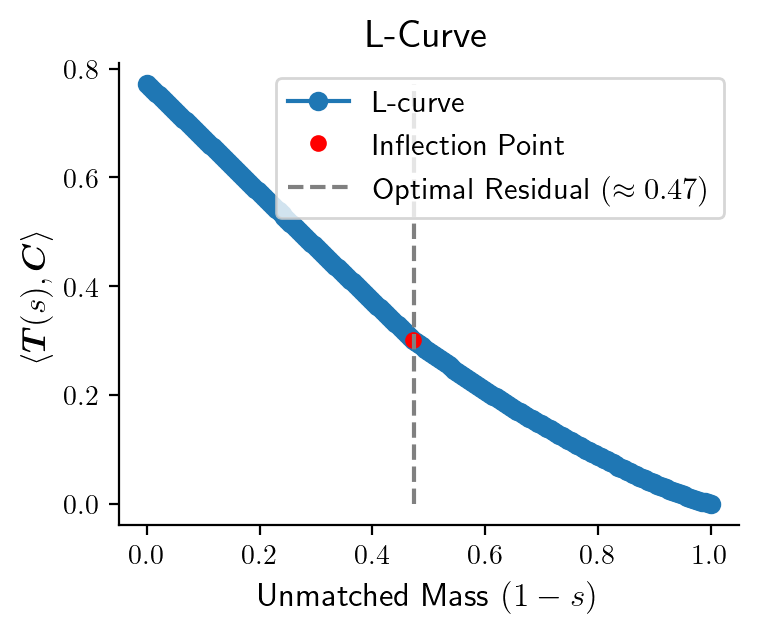

In [7]:
print(f"Inflection occurs at mreg value: {1-inflection_mreg.item():.3f}")
plt.figure(figsize=(4, 3))
plt.plot(residuals, transport_costs, 'o-', label=r"L-curve")
plt.plot(inflection_residual, inflection_cost, 'ro', markersize=5, label="Inflection Point")
plt.vlines(x=90/190,
           ymin=0, 
           ymax=max(transport_costs), 
           color='gray',
           linestyles='dashed', 
           label=r'Optimal Residual $(\approx 0.47)$')
plt.ylabel(r"$\langle \bm{T}(s), \bm{C}\rangle$", fontsize=12)
plt.xlabel("Unmatched Mass $(1-s)$", fontsize=12)
plt.title(r"L-Curve", fontsize=14)
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11

plt.legend(fontsize=11)
plt.grid(False)
sns.despine(trim=False)
plt.savefig('./paper-figures/synthetic/l-curve-balanced-matching.png', 
            dpi=600,
            bbox_inches='tight')
plt.show()

In [8]:
# fit unbalanced soft-matching to the representations
unsm_metric = UnbalancedSoftMatch(mass_reg=inflection_mreg)
unsm_score = unsm_metric.fit_kfold_score(torch.tensor(z1_noisy), torch.tensor(z2_noisy))

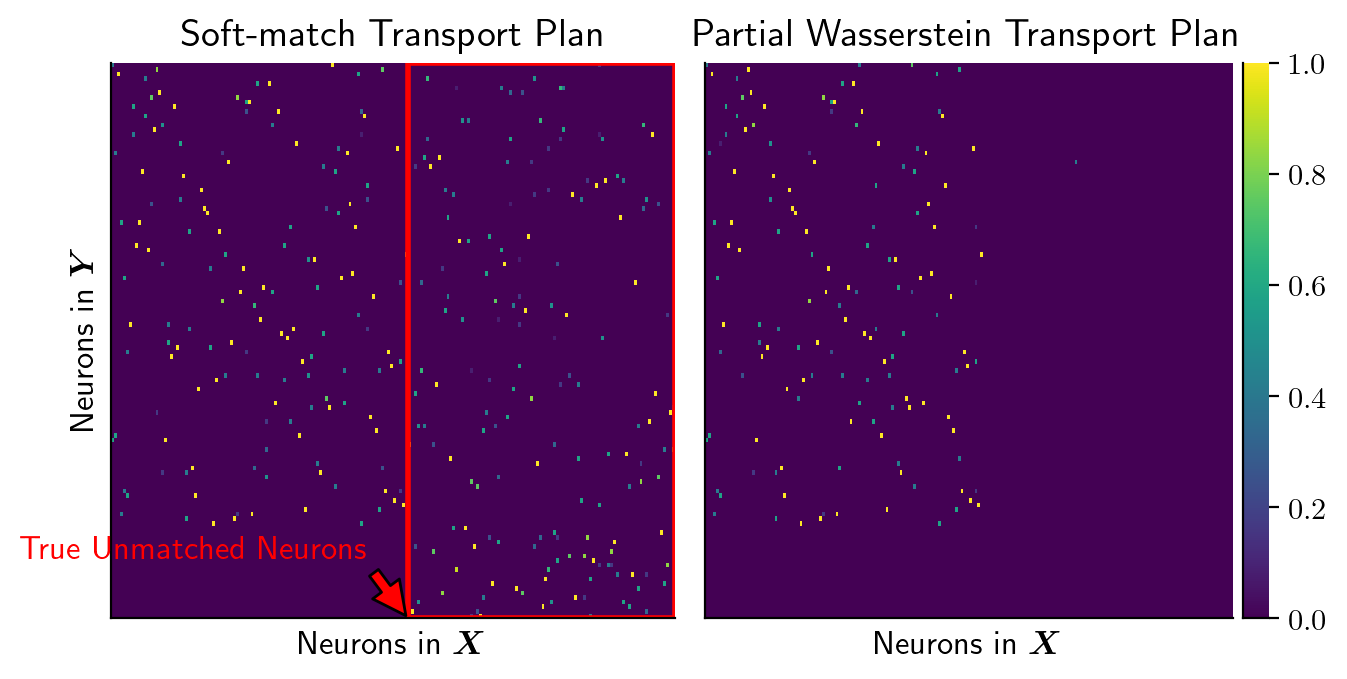

In [9]:
viz1 = sm.transform
if viz1.sum() > 0:
    viz1 = viz1 / viz1.max()

viz2 = unsm_metric.transform
if viz2.sum() > 0:
    viz2 = viz2 / viz2.max()

# define the region corresponding to noisy neurons
n_rows, n_cols = viz1.shape
noisy_region_rows = 120
noisy_region_cols = 90

# create figure and subplots with gridspec to control width ratios
fig, axes = plt.subplots(1, 2, 
                         figsize=(4*1.75, 2*1.75),
                         gridspec_kw={"width_ratios": [1, 1]})

# soft-match transport plan
ax1 = sns.heatmap(viz1, cmap='viridis', cbar=False, ax=axes[0])
axes[0].set_xlabel(r'Neurons in $\bm{X}$', fontsize=12)
axes[0].set_ylabel(r'Neurons in $\bm{Y}$', fontsize=12)
axes[0].set_title(r'Soft-match Transport Plan', fontsize=14)
axes[0].set_xticks([])
axes[0].set_yticks([])

# add a red rectangle to highlight noisy neurons
if n_rows >= noisy_region_rows and n_cols >= noisy_region_cols:
    rect = patches.Rectangle((n_cols - noisy_region_cols, n_rows - noisy_region_rows),
                             noisy_region_cols, noisy_region_rows,
                             linewidth=2, edgecolor='red', facecolor='none')
    ax1.add_patch(rect)

    bl_x = 100#start_col
    bl_y = 120#start_row + noisy_region_rows

    # annotate the rectangle
    axes[0].annotate("True Unmatched Neurons", 
                     xy=(bl_x, bl_y),
                     xycoords='data',
                     xytext=(bl_x - noisy_region_cols * 0.15, bl_y - noisy_region_rows * 0.15),
                     textcoords='data',
                     arrowprops=dict(facecolor='red', shrink=0.05),
                     horizontalalignment='right', verticalalignment='top',
                     fontsize=12, color='red')

# unbalanced transport plan
# this is me being super nitpicky about how i want the 
# plot aspect ratios to be exactly balanced
divider = make_axes_locatable(axes[1])
cax = divider.append_axes("right", size="5%", pad=0.05)  # create space for the colorbar

ax2 = sns.heatmap(viz2, cmap='viridis', cbar=True, ax=axes[1], cbar_ax=cax)  # assign colorbar to cax
axes[1].set_xlabel(r'Neurons in $\bm{X}$', fontsize=12)
axes[1].set_title(r'Partial Wasserstein Transport Plan', fontsize=14)
axes[1].set_xticks([])
axes[1].set_yticks([])

sns.despine(trim=True)
plt.tight_layout()
plt.savefig('./paper-figures/synthetic/transport-plan-simulation.png', dpi=600)
plt.show()